# Iris Flower Classification using Machine Learning     (Markdown)

Import Libraries                                         (Code)

Load Dataset                                             (Code)

Convert to DataFrame                                     (Code)

Data Exploration                                         (Code)

Observations                                             (Markdown)

Data Visualization                                       (Code)

Observations                                             (Markdown)

Machine Learning                                         (Code)

Results                                                  (Code)

Conclusion                                               (Markdown)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Iris dataset

from sklearn.datasets import load_iris

iris = load_iris()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [21]:
# Convert the dataset into a pandas DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["Species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Replace numeric labels with flower names

df["Species"] = df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display first five rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [5]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [6]:
# Display statistical summary

df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Observation

- The dataset contains 150 flower samples.
- The average sepal length is approximately 5.84 cm.
- The average petal length is approximately 3.76 cm.
- The dataset has no missing values and all numerical features are within a reasonable range.
- The statistical summary helps us understand the distribution of each feature before building the machine learning model.

In [7]:
# Count the number of flowers in each species

print(df["Species"].value_counts())

Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


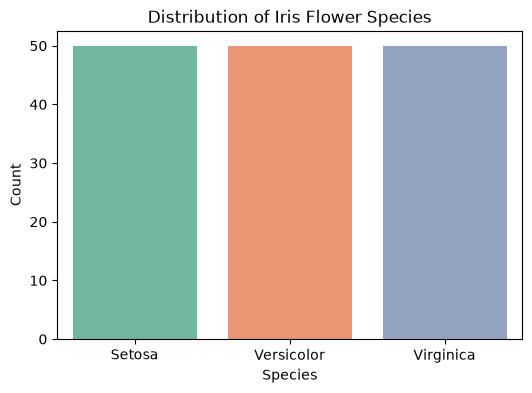

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="Species", data=df, hue="Species", palette="Set2", legend=False)

plt.title("Distribution of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## Observation

- The dataset contains three flower species: Setosa, Versicolor and Virginica.
- Each species has 50 samples.
- The dataset is perfectly balanced, which is beneficial for training a classification model because no class is overrepresented.

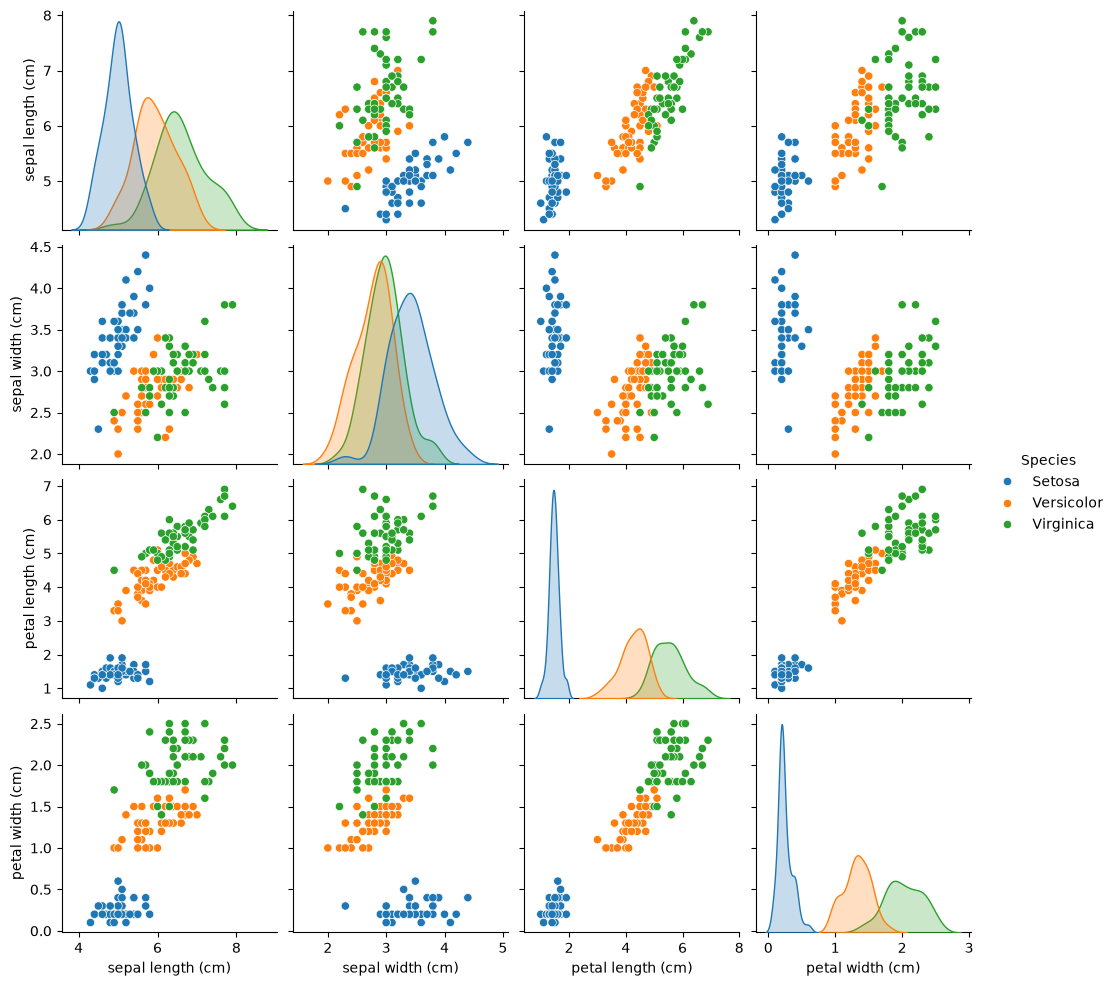

In [9]:
# Pair Plot

sns.pairplot(df, hue="Species")

plt.show()

## Observation

- The Pair Plot shows relationships between all numerical features.
- Setosa is clearly separated from the other two species.
- Versicolor and Virginica have some overlap but can still be distinguished using petal measurements.
- Petal length and petal width appear to be the most important features for classification.

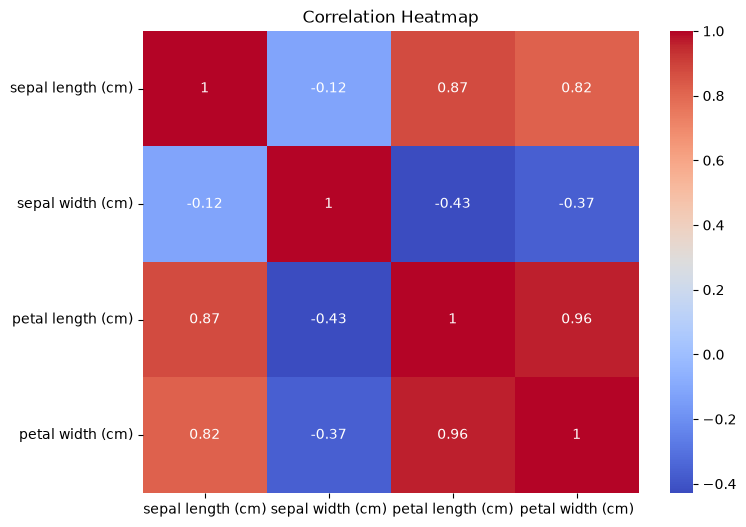

In [10]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- Petal length and petal width have a strong positive correlation.
- Sepal measurements have a weaker correlation with the petal measurements.
- The heatmap helps identify which features are most useful for building the classification model.

In [11]:
# Define features and target

X = df.drop("Species", axis=1)

y = df["Species"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [12]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


## Observation

- The dataset is divided into training and testing sets.
- 80% of the data (120 samples) is used for training the model.
- 20% of the data (30 samples) is reserved for testing the model.
- Splitting the dataset helps evaluate how well the model performs on unseen data.

In [13]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create the model

model = DecisionTreeClassifier(random_state=42)

# Train the model

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [14]:
# Predict the test data

y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [15]:
# Import accuracy score

from sklearn.metrics import accuracy_score

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


## Observation

- The Decision Tree model was successfully trained using the training dataset.
- The model was tested on unseen data.
- The accuracy score indicates how well the model predicts the flower species.
- A high accuracy shows that the selected features are effective for classification.

In [16]:
# Import required libraries

from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


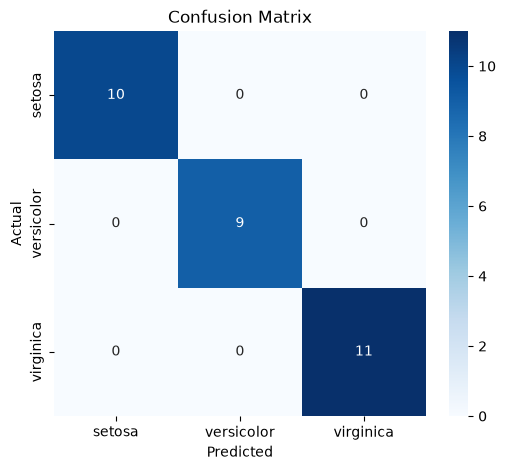

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Save automatically
plt.savefig(
    'screenshots/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Observation

- The confusion matrix compares the actual and predicted flower species.
- Most values appear on the diagonal, indicating correct predictions.
- Very few or no misclassifications indicate that the model performs well.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Observation

- The model achieved high precision, recall and F1-score for all three flower species.
- This indicates that the classifier performs consistently across different classes.

In [19]:
# Predict a new flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Setosa


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


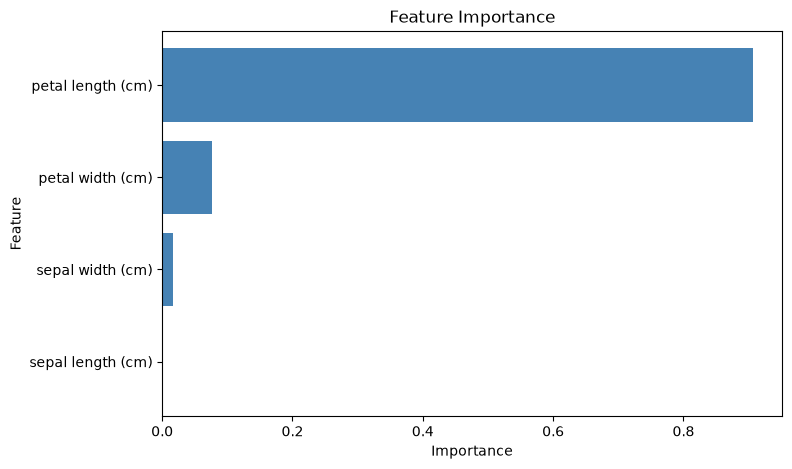

,Feature,Importance
2,petal length (cm),0.906143
3,petal width (cm),0.077186
1,sepal width (cm),0.016670
0,sepal length (cm),0.000000


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="steelblue"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()

# Save automatically to screenshots folder
plt.savefig(
    "screenshots/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_importance

# Conclusion

This project successfully built a Machine Learning classification model using the Iris dataset.

The dataset was explored and visualized using various statistical techniques and graphs. A Decision Tree Classifier was trained to classify Iris flowers into Setosa, Versicolor and Virginica based on four flower measurements.

The model achieved high accuracy on the test dataset, demonstrating that Machine Learning can effectively classify flower species using numerical features.